In [1]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler

import os
import sys
import logging
import warnings
from utils import *

/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load file path from ocean
adata_infile = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/All_Cell_Types.h5ad'
adata_infile_fiber = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/Myofiber_scsn_RNA.h5ad'
adata_male_file = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_male.h5ad'
adata_female_file = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad'
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/tmp'

In [3]:
adata_male = sc.read_h5ad(adata_male_file)
adata_female = sc.read_h5ad(adata_female_file)

# Myofiber analysis

In [102]:
adata_female

AnnData object with n_obs × n_vars = 76546 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'DNA_DAMAGE_CHECKPOINT', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR', 'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS', 'GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_CITRATE_CYCLE_TCA_CYCLE', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_OXIDATIVE_PHOSPHORYLATION', 'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM', 'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM', 'Atrophy Pathway'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors

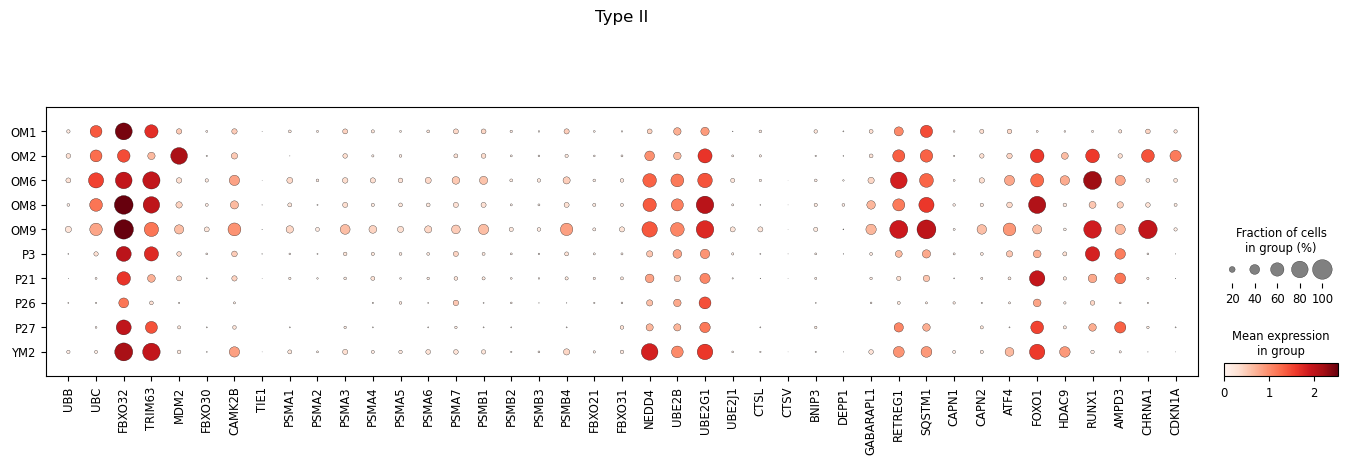

In [112]:
#subset by type
adata_female_type_II = adata_female[adata_female.obs['Annotation'] == 'Type II'].copy()
adata_female_type_I = adata_female[adata_female.obs['Annotation'] == 'Type I'].copy()
# gene expression dot plots of atrophy pathway
sc.pl.dotplot(adata_female_type_II, title='Type II', var_names=['UBB','UBC','FBXO32','TRIM63','MDM2','FBXO30','CAMK2B','TIE1','PSMA1','PSMA2','PSMA3','PSMA4','PSMA5','PSMA6','PSMA7','PSMB1','PSMB2','PSMB3','PSMB4','FBXO21','FBXO31','NEDD4','UBE2B','UBE2G1','UBE2J1','CTSL','CTSV','BNIP3','DEPP1','GABARAPL1','RETREG1','SQSTM1','CAPN1','CAPN2','ATF4','FOXO1','HDAC9','RUNX1','AMPD3','CHRNA1','CDKN1A'], groupby='sample', dendrogram=False)


In [ ]:
# count the number of cells in each age
display(adata_male.obs['sample'].value_counts())

sample
OM5    11986
P5      8992
OM7     5693
P13     2949
Name: count, dtype: int64

## Molecular age (pseudotime based) of each sample

/tmp/ipykernel_101622/2432330064.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_summary_df_all_annotations = obs_df_valid_pt.groupby(['sample', annotation_col]).agg(


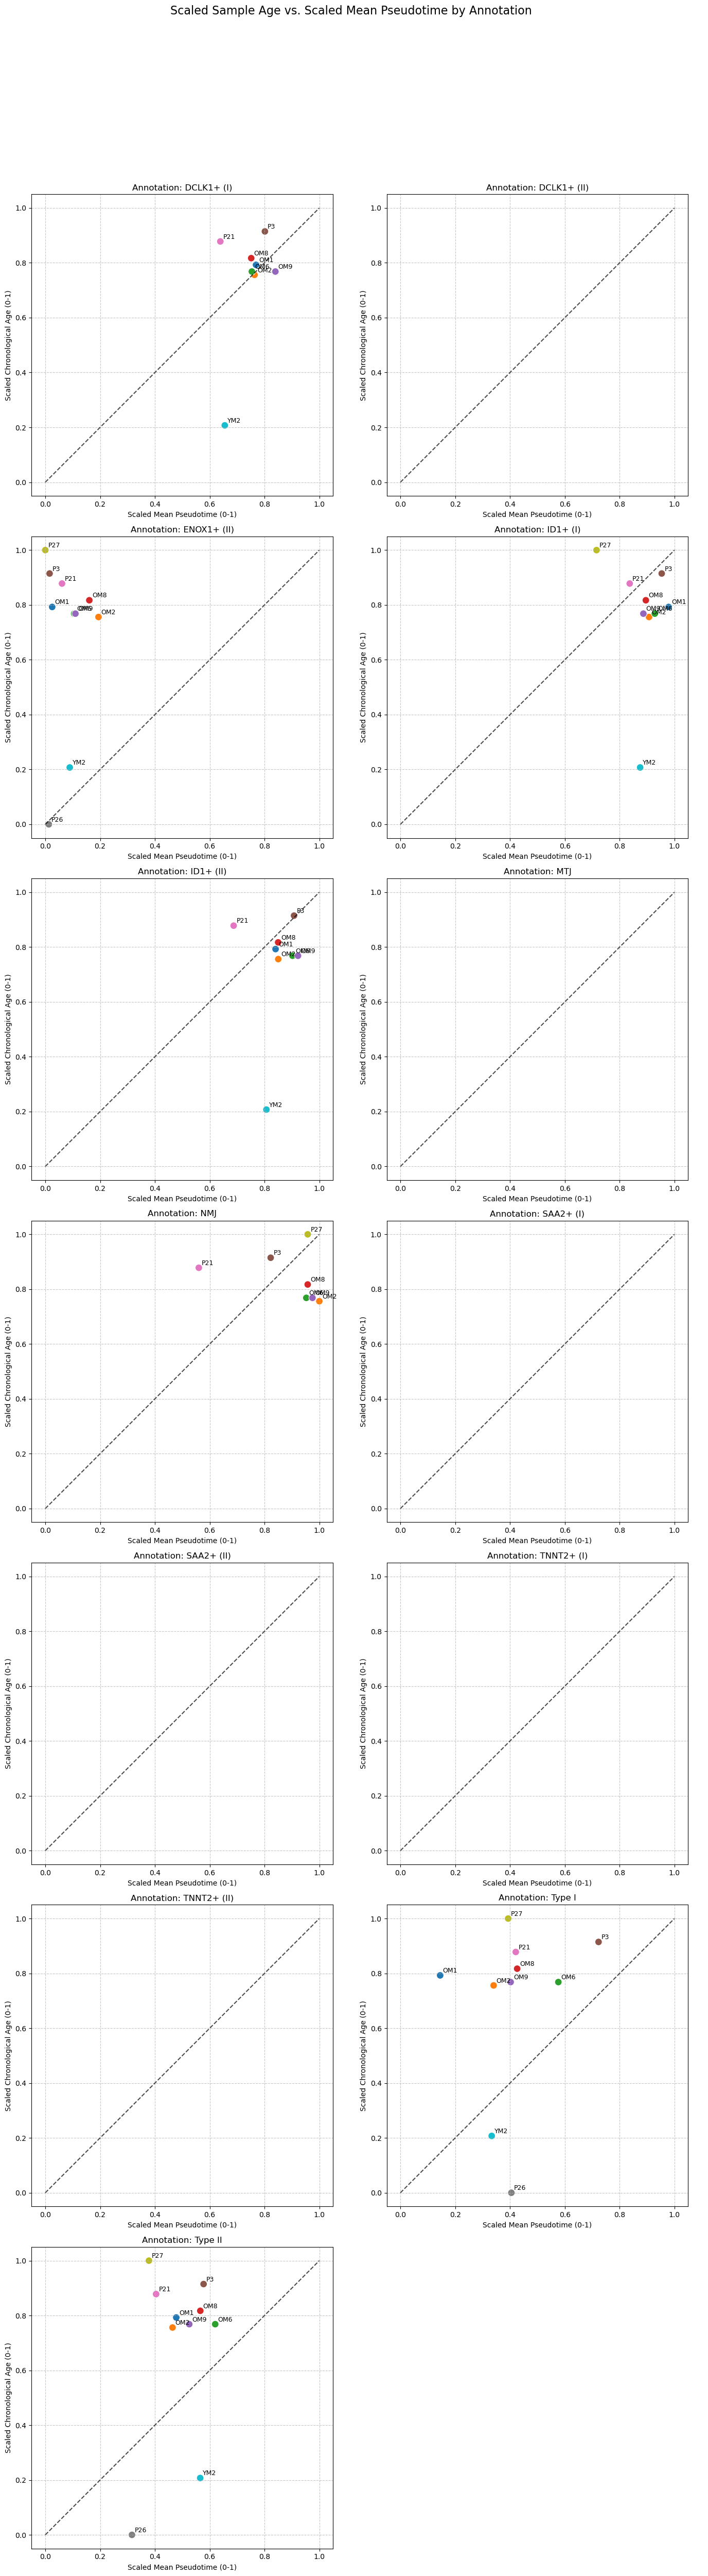

In [218]:
fig_by_annotation, summary_df_all = plot_age_vs_pseudotime_by_annotation(
    adata_female,
    annotation_col='Annotation', # Make sure this column name is correct
    point_size=100,
    n_subplot_cols=2 # Or 1 if you only have 'Type I' and 'Type II' and want them stacked
)

# AUCell activity scoring of specific pathways

In [29]:
# load geneset of interest
# geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
#                "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt"]
# geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt)
geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/DNA_DAMAGE_CHECKPOINT.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/GOBP_DNA_DAMAGE_RESPONSE.v2024.1.Hs.gmt", 
               "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/GOBP_DNA_REPAIR.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/HALLMARK_DNA_REPAIR.v2024.1.Hs.gmt",
               "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/REACTOME_DNA_REPAIR.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/DNA_repair/REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS.v2024.1.Hs.gmt"]
geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt)
# get the number of rows in each unique geneset
geneset_size = geneset_df['geneset'].value_counts()
display(geneset_size)

# custom_atrophy_pathway = ["UBB","UBC","FBXO32","TRIM63","MDM2","FBXO30","CAMK2B","TIE1","PSMA1","PSMA2","PSMA3","PSMA4","PSMA5","PSMA6","PSMA7","PSMB1","PSMB2","PSMB3","PSMB4","FBXO21","FBXO31","NEDD4","UBE2B","UBE2G1","UBE2J1","CTSL","CTSV","BNIP3","DEPP1","GABARAPL1","MAP1LC3","RETREG1","SQSTM1","CAPN1","CAPN2","ATF4","FOXO1","FOXO3A","HDAC9","RUNX1","AMPD3","CHRNA1","CDKN1A"]
# geneset_df = pd.DataFrame({'geneset': "Atrophy Pathway (PMID: 31325479)", 'genesymbol': custom_atrophy_pathway})
# geneset_df


geneset
GOBP_DNA_DAMAGE_RESPONSE                906
GOBP_DNA_REPAIR                         615
REACTOME_DNA_REPAIR                     332
HALLMARK_DNA_REPAIR                     150
REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS     68
DNA_DAMAGE_CHECKPOINT                    20
Name: count, dtype: int64

In [40]:
%%time
decoupler.run_aucell(
    adata_male,
    geneset_df,
    source="geneset",
    target="genesymbol",
    use_raw=False,
)

CPU times: user 14min 27s, sys: 31min 30s, total: 45min 57s
Wall time: 5min 22s


In [77]:
dna_damage_and_repair_pathways = [
    "DNA_DAMAGE_CHECKPOINT",
    "GOBP_DNA_DAMAGE_RESPONSE",
    "GOBP_DNA_REPAIR",
    "HALLMARK_DNA_REPAIR",
    "REACTOME_DNA_REPAIR",
    "REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS"
]
metabolic_pathways = [
    "GOBP_FATTY_ACID_BETA_OXIDATION",
    "KEGG_CITRATE_CYCLE_TCA_CYCLE",
    "KEGG_GLYCOLYSIS_GLUCONEOGENESIS",
    "KEGG_OXIDATIVE_PHOSPHORYLATION",
    "REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM",
    "REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM"
]
#adata_male.obs["Atrophy Pathway"] = adata_male.obsm["aucell_estimate"]["Atrophy Pathway (PMID: 31325479)"]

### Plot samples ordered by score to select outliers for bar-plot comparitive analysis between cohorts

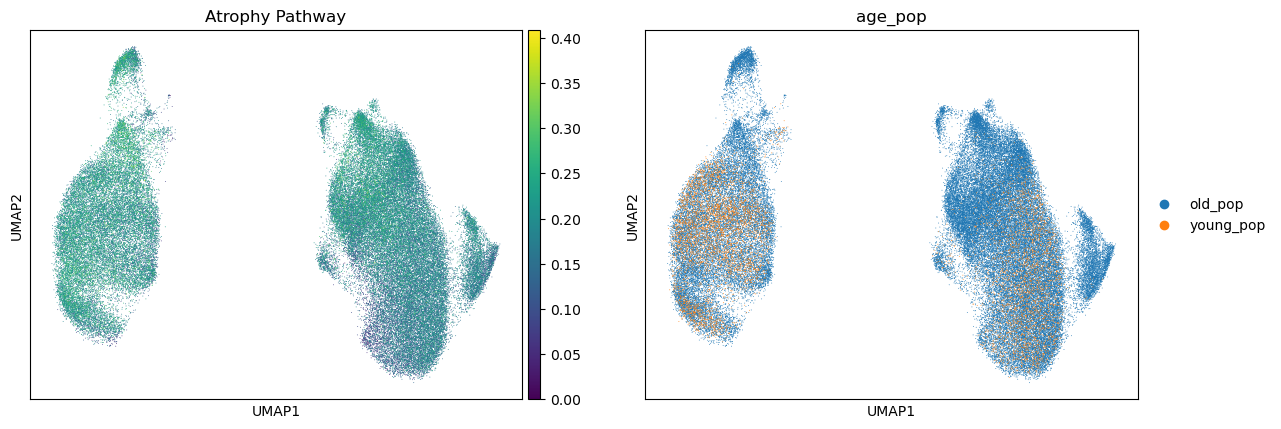

In [103]:
sc.pl.umap(adata_female, color=["Atrophy Pathway", 'age_pop'])

In [43]:
# save adata
adata_male.write_h5ad(os.path.join(out_tmp, 'myofibers_male.h5ad'))

### Dotplot over all samples to show activities of multiple pathways

In [ ]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = adata_male.obs[['sample', 'age', 'Annotation'] + dna_damage_and_repair_pathways].copy()
plot_pathway_dotplot_by_age(
    df_cell_level=cell_level_scores_df, # Your cell-level data
    score_cols=dna_damage_and_repair_pathways,      # List of pathway score columns
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation='Type II',         # Or whichever annotation you want
    figsize=(12, 7),                    # Adjust figure size
    min_dot_size=30,
    max_dot_size=600,
    dot_size_scale_factor=0.1, # YOU WILL LIKELY NEED TO TUNE THIS FACTOR!
                               # If cell counts are very large (e.g., 1000s),
                               # this factor should be small (e.g., 0.01, 0.1).
                               # If cell counts are small (e.g., 10s, 100s),
                               # this factor can be larger (e.g., 1.0, 5.0).
                               # The goal is to get a good visual spread of dot sizes.
    cmap_name="RdYlBu_r",               # Red-Yellow-Blue rseversed, hot is red
    value_legend_title="Mean Pathway Score",
    size_legend_title="# Cells in Sample"
)

# Downsample myofibers to include size matched old and young cohorts (n=2)

In [210]:
adata_female_downsampled = adata_female[adata_female.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9'])].copy()
adata_male_downsampled = adata_male[adata_male.obs['sample'].isin(['P13', 'P5', 'OM5', 'OM7'])].copy()

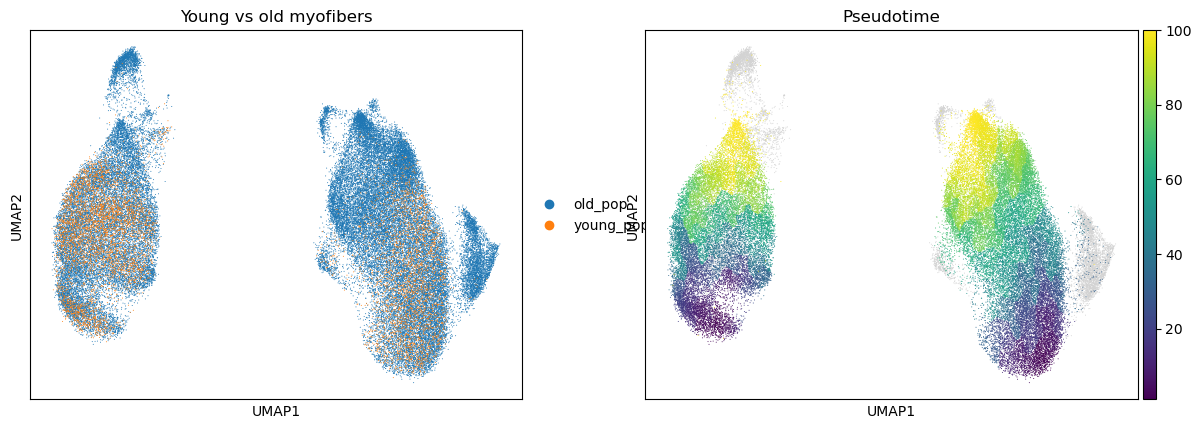

In [211]:
sc.pl.umap(adata_female_downsampled, color=['age_pop','Pseudotime'], title='Young vs old myofibers')

In [212]:
# get a df of sample ID, sample score per cell type and age
sample_scores = adata_female_downsampled.obs[['sample','age', 'Annotation']+dna_damage_and_repair_pathways].copy()
# average scores per sample and group by Annotation
sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()
sample_scores_avg.head()

/tmp/ipykernel_101622/1457332631.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_scores_avg = sample_scores.groupby(['sample', 'Annotation']).mean().reset_index()


,sample,Annotation,age,DNA_DAMAGE_CHECKPOINT,GOBP_DNA_DAMAGE_RESPONSE,GOBP_DNA_REPAIR,HALLMARK_DNA_REPAIR,REACTOME_DNA_REPAIR,REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS
0,OM6,Type I,80.0,0.080590,0.091547,0.078895,0.048692,0.062596,0.076238
1,OM6,Type II,80.0,0.067040,0.086907,0.074199,0.046858,0.060909,0.080895
2,OM6,DCLK1+ (I),80.0,0.084496,0.090235,0.077153,0.049560,0.061177,0.076017
3,OM6,DCLK1+ (II),80.0,0.069671,0.081837,0.071223,0.052990,0.061904,0.086786
4,OM6,ENOX1+ (II),80.0,0.064664,0.087943,0.074548,0.045476,0.061395,0.078155


## Plots wrt age

In [213]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = adata_female_downsampled.obs[['sample', 'age', 'Annotation', 'Pseudotime'] + dna_damage_and_repair_pathways].copy()
# geneset_sizes_data = {
#     'KEGG_OXIDATIVE_PHOSPHORYLATION': 132,
#     'GOBP_FATTY_ACID_BETA_OXIDATION': 75,
#     'KEGG_GLYCOLYSIS_GLUCONEOGENESIS': 62,
#     'KEGG_CITRATE_CYCLE_TCA_CYCLE': 31,
#     'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM': 21,
#     'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM': 14
# }
geneset_sizes_data = {
    'GOBP_DNA_DAMAGE_RESPONSE': 906,
    'GOBP_DNA_REPAIR': 615,
    'REACTOME_DNA_REPAIR': 332,
    'HALLMARK_DNA_REPAIR': 150,
    'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS': 68,
    'DNA_DAMAGE_CHECKPOINT': 20
}
geneset_sizes_series = pd.Series(geneset_sizes_data)

# Your list of score columns
score_cols_to_plot = list(geneset_sizes_series.index)

/tmp/ipykernel_101622/286968175.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='x_position', y=score, data=df_for_plot, ax=ax, palette="tab10", width=box_width, fliersize=2) # fliersize controls outlier point size
/tmp/ipykernel_101622/286968175.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='x_position', y=score, data=df_for_plot, ax=ax, palette="tab10", width=box_width, fliersize=2) # fliersize controls outlier point size
/tmp/ipykernel_101622/286968175.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='x_position',

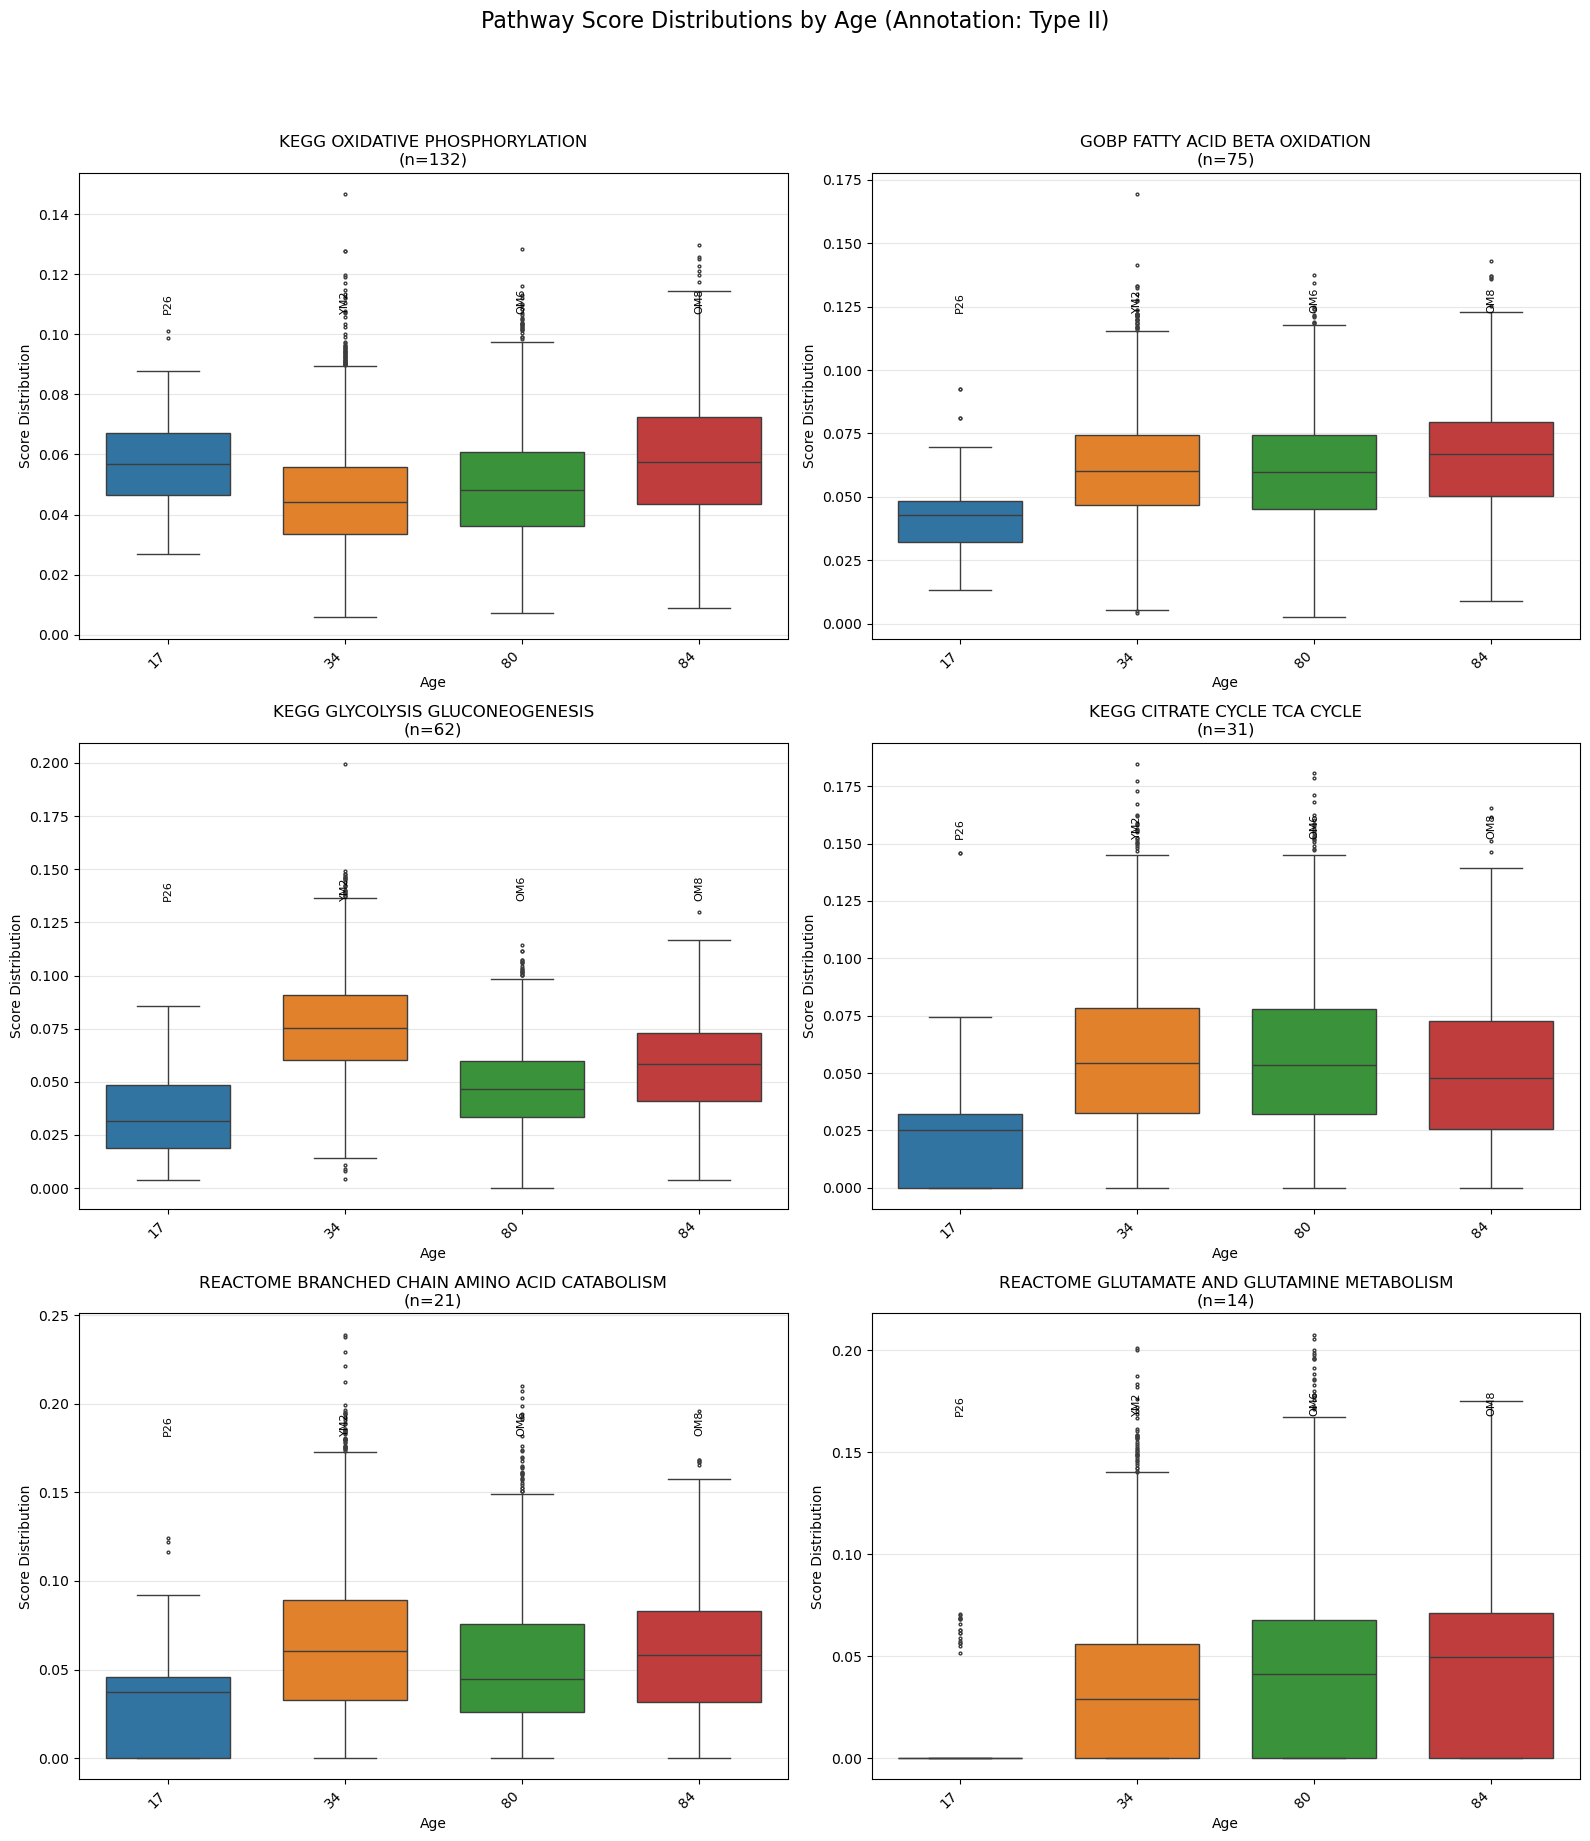

In [197]:
plot_pathway_box_distributions_by_age( # Note the new function name
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    geneset_sizes=geneset_sizes_series,
    age_col='age',
    sample_col='sample',
    annotation_col='Annotation',
    target_annotation='Type II', # Using 'Type I' as in your image example
    filter_quantile_to_keep_top=None, # or 0.75, etc.
    n_subplot_cols=2, # As in your image example
    box_width=0.7, # Adjust for aesthetics
    sample_label_y_offset_factor=0.08 # May need adjustment
)

## Plots wrt pseudotime

In [214]:
obs_df = adata_female_downsampled.obs[['sample', 'age', 'Annotation', 'Pseudotime']].copy()
obs_df_valid_pt = obs_df.dropna(subset=['Pseudotime'])

/tmp/ipykernel_101622/4050015747.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_pseudotime_summary = obs_df_valid_pt.groupby(['sample', 'Annotation']).agg( # or just ['sample']


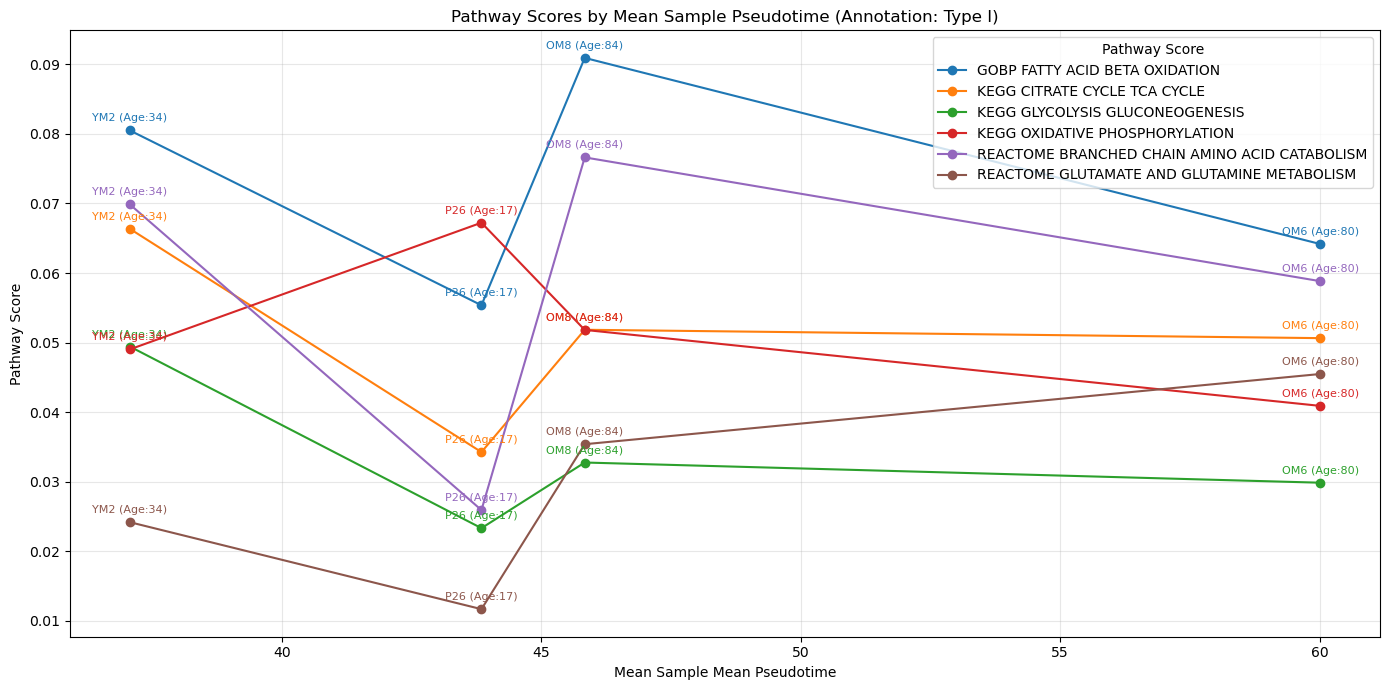

In [200]:
if obs_df_valid_pt.empty:
    print("No cells with valid pseudotime values. Cannot calculate mean pseudotime.")
else:
    # Group by sample AND Annotation if you want means specific to that combination
    # Or just by sample if pseudotime should be an overall sample average
    sample_pseudotime_summary = obs_df_valid_pt.groupby(['sample', 'Annotation']).agg( # or just ['sample']
        mean_pseudotime=('Pseudotime', 'mean'),
        age=('age', 'first') # Keep original age
    ).reset_index()

    # Now merge the mean_pseudotime into this pathway score DataFrame
    df_for_plot = pd.merge(
        sample_scores_avg, # Your DataFrame with averaged pathway scores
        sample_pseudotime_summary[['sample', 'Annotation', 'mean_pseudotime']], # Only need these columns for merging
        on=['sample', 'Annotation'], # Merge keys
        how='left' # Use 'left' to keep all pathway score rows
    )

    if 'mean_pseudotime' not in df_for_plot.columns or df_for_plot['mean_pseudotime'].isnull().all():
        print("Merging failed or no mean_pseudotime values available. Check your dataframes.")
    else:
        # --- Call the plotting function ---
        plot_multi_score_lines_by_pseudotime(
            df_with_scores_and_pseudotime=df_for_plot,
            score_cols=metabolic_pathways, # Your list of pathway score columns
            pseudotime_col='mean_pseudotime',
            sample_col='sample',
            age_col_for_labeling='age', # Will show sample name and original age
            annotation='Type I' # Or your desired annotation, or None
        )

#### Line plots per cell over pseudotime

/tmp/ipykernel_101622/2263936671.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _default_colors = plt.cm.get_cmap('tab10').colors
/tmp/ipykernel_101622/2263936671.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _default_colors = plt.cm.get_cmap('tab10').colors
/tmp/ipykernel_101622/2263936671.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _default_colors = plt.cm.get_cmap('tab10').colors
/tmp/ipykernel_101622/2263936671.py:55: MatplotlibDeprecat

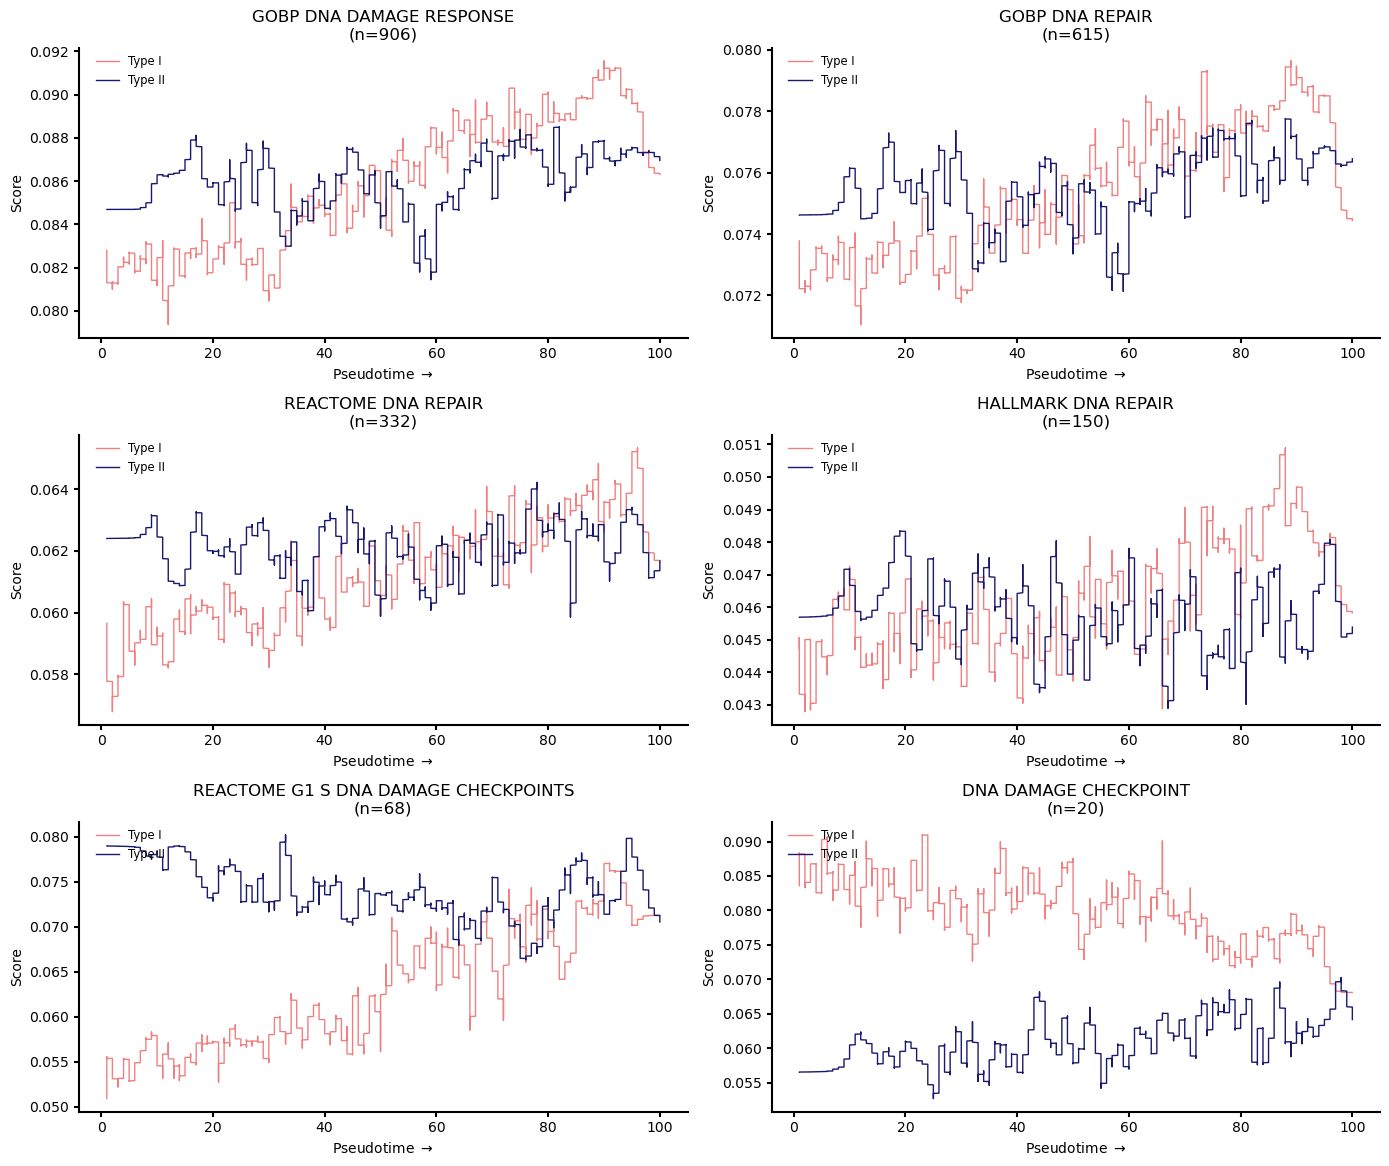

In [215]:
# Colors for 'Type I' and 'Type II'
plot_colors = {'Type I': '#F08080', 'Type II': '#191970'}
legend_labels = {'Type I': 'Type I', 'Type II': 'Type II'}

plot_multi_smoothed_lines_from_df(
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    pseudotime_key='Pseudotime',
    group_by_key='Annotation',
    smoothing_method='gaussian',          # Specify method
    smoothing_strength=70.0,             # Fraction for LOWESS (e.g., 0.05 to 0.2)
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=['Type I', 'Type II'],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=2,
    figsize_per_subplot=(7, 4),
    common_xlabel=r"Pseudotime $\rightarrow$",
    common_ylabel="Score",
    common_ylim=None, common_xticks_list=None, common_yticks_list=None,
    common_legend_loc=(0.02, 0.85), common_line_kwargs={'linewidth': 1.0},
    main_figure_title=None,
    debug_prints_for_subp_plot_func=False
)


# DEGs and gsea pathway analysis

#### Do size matching to get a more balanced sample size for DEG significance

In [151]:
adata_female_downsampled.obs['age_pop'] = pd.Categorical(adata_female_downsampled.obs['age_pop'], categories=["old_pop", "young_pop"], ordered=True)

In [165]:
bdata = adata_female_downsampled[adata_female_downsampled.obs.Annotation == "Type I"].copy()
bdata

AnnData object with n_obs × n_vars = 23407 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'DNA_DAMAGE_CHECKPOINT', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR', 'REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS', 'GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_CITRATE_CYCLE_TCA_CYCLE', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_OXIDATIVE_PHOSPHORYLATION', 'REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM', 'REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM', 'Atrophy Pathway'
    var: 'features'
    uns: 'Annotation_colors', 'Final_annotation2_colors', 'Final_annotation3_colors', 'Final_annotation4_colors', 'Final_annotation_colors', 'Sex_colors', 'age_pop_colors', 'anno_0713_colors', 'anno_0715_colors', 'fiber_class_V1_colors', 'integrated_snn_res.0.8_colors', 'integrated_snn_res.2.5_colors', 'integrated_snn_res.2_colors

In [166]:
sc.tl.rank_genes_groups(bdata,
                        groupby='age_pop',
                        use_raw=False,
                        method='wilcoxon',
                        groups=["old_pop"],
                        reference='young_pop')

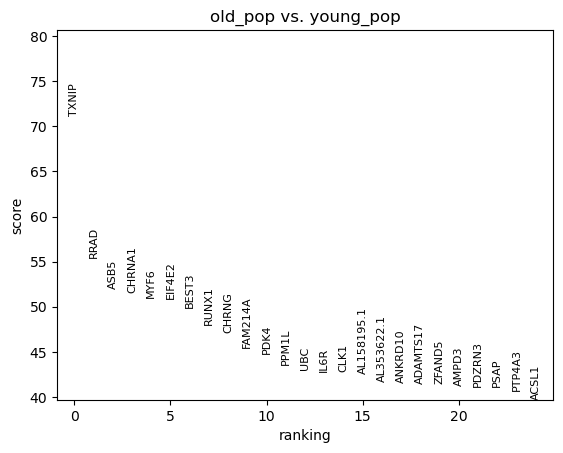

In [167]:
sc.pl.rank_genes_groups(bdata, n_genes=25, sharey=False)

In [168]:
# get deg result
result = bdata.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key: result[key][group]
    for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
degs.head()

,old_pop_names,old_pop_scores,old_pop_pvals,old_pop_pvals_adj,old_pop_logfoldchanges
0,TXNIP,71.215881,0.0,0.0,3.347214
1,RRAD,55.443909,0.0,0.0,2.819716
2,ASB5,51.990772,0.0,0.0,2.270588
3,CHRNA1,51.537991,0.0,0.0,6.147987
4,MYF6,50.994728,0.0,0.0,3.057939


In [172]:
# subset up or down regulated genes
degs_sig = degs[degs.old_pop_pvals_adj < 0.01]
degs_up = degs_sig[degs_sig.old_pop_logfoldchanges > 0]
degs_dw = degs_sig[degs_sig.old_pop_logfoldchanges < 0]

In [173]:
degs_up.shape

(6447, 5)

In [174]:
degs_dw.shape

(791, 5)

In [175]:
enr_up = gp.enrichr(degs_up.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [176]:
enr_up.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Intracellular Protein Transport (GO:0006886),185/326,3.740609e-20,1.856838e-16,0,0,2.810173,1.257059e+02,IPO13;VPS29;MTCH1;IPO11;NDUFA13;NUP107;CSE1L;P...
1,GO_Biological_Process_2025,Macroautophagy (GO:0016236),101/162,2.931945e-15,7.277087e-12,0,0,3.520204,1.177970e+02,RETREG3;PJVK;AUP1;PHB2;ZFYVE1;ZFYVE26;TBK1;LAM...
2,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,224/455,2.125642e-14,3.517229e-11,0,0,2.075896,6.535361e+01,IPP;KEAP1;UBE2L3;DCAF1;PSMD9;HERC4;PSMD6;PSMD7...
3,GO_Biological_Process_2025,Proteasomal Protein Catabolic Process (GO:0010...,186/372,5.860062e-13,7.272337e-10,0,0,2.134962,6.013217e+01,MIDN;UBXN2B;UBE3D;UBXN2A;UBE2D3;IPP;KEAP1;UBE2...
4,GO_Biological_Process_2025,Protein Ubiquitination (GO:0016567),180/369,2.058578e-11,2.043756e-08,0,0,2.030895,4.997306e+01,UBE3D;UBE2D2;FBXO28;UBE2D3;KEAP1;UBE2D1;UBE3B;...
...,...,...,...,...,...,...,...,...,...,...
4959,GO_Biological_Process_2025,Adenylate Cyclase-Inhibiting G Protein-Coupled...,2/56,9.999964e-01,9.999966e-01,0,0,0.077574,2.822864e-07,GNAI3;PRKCA
4960,GO_Biological_Process_2025,Sensory Perception of Bitter Taste (GO:0050913),1/38,9.999965e-01,9.999966e-01,0,0,0.056670,1.997060e-07,BPNT1
4961,GO_Biological_Process_2025,"GPCR Sgnlng Pway, Coupled to Cyclic Nucleotide...",1/50,9.999965e-01,9.999966e-01,0,0,0.042754,1.492117e-07,DHX34
4962,GO_Biological_Process_2025,Detection of Chemical Stimulus Involved in Sen...,1/41,9.999966e-01,9.999966e-01,0,0,0.052408,1.760014e-07,BPNT1


<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_101622/3343746717.py:2: SyntaxWarning: invalid escape sequence '\('
  enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]


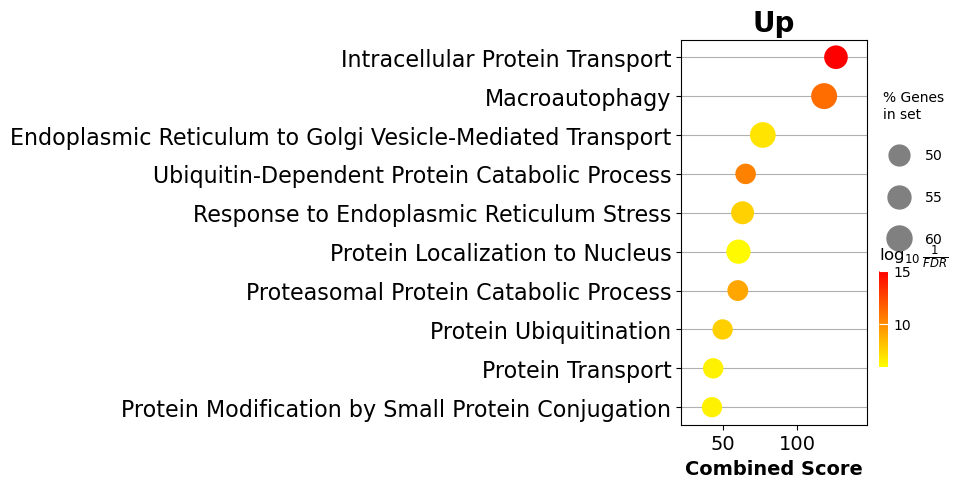

In [177]:
# dotplot
enr_up.res2d.Term = enr_up.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_up.res2d, figsize=(3,5), title="Up", cmap = plt.cm.autumn_r)
plt.show()

In [178]:
enr_dw = gp.enrichr(degs_dw.old_pop_names,
                    gene_sets='GO_Biological_Process_2025',
                    outdir=None)

In [179]:
enr_dw.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Muscle Contraction (GO:0006936),31/97,3.293860e-20,9.084467e-17,0,0,11.830801,530.725513,RYR1;MYLK2;ROCK2;LMOD1;MYL6B;MYOM2;RYR3;CLCN1;...
1,GO_Biological_Process_2025,Actomyosin Structure Organization (GO:0031032),29/85,6.875970e-20,9.481963e-17,0,0,13.016428,574.332546,MYOM1;ROCK2;LMOD1;MYOM2;MYPN;MYOM3;EPB41L4B;EP...
2,GO_Biological_Process_2025,Myofibril Assembly (GO:0030239),23/51,2.734655e-19,2.514060e-16,0,0,20.515392,876.891708,MYOM1;MYBPC1;MYBPC2;ADPRHL1;ACTN2;TMOD4;TPM1;L...
3,GO_Biological_Process_2025,Sarcomere Organization (GO:0045214),18/34,5.635273e-17,3.885521e-14,0,0,27.932891,1045.106361,MYOM1;MYBPC1;MYBPC2;TPM1;MYOM2;MYPN;MYOM3;OBSC...
4,GO_Biological_Process_2025,Striated Muscle Contraction (GO:0006941),18/55,1.684618e-12,9.292354e-10,0,0,12.065872,327.099536,RYR1;MYLK2;DTNA;PGAM2;TNNC2;TPM1;STAC3;ATP1A2;...
...,...,...,...,...,...,...,...,...,...,...
2753,GO_Biological_Process_2025,Adenylate Cyclase-Activating G Protein-Coupled...,1/153,9.979641e-01,9.988350e-01,0,0,0.158703,0.000323,ADCY2
2754,GO_Biological_Process_2025,DNA Metabolic Process (GO:0006259),4/302,9.980277e-01,9.988350e-01,0,0,0.322540,0.000637,RPS3;INO80;TOP1;SMC1A
2755,GO_Biological_Process_2025,Lipid Metabolic Process (GO:0006629),3/259,9.981107e-01,9.988350e-01,0,0,0.281860,0.000533,PER2;ACSL3;PPARA
2756,GO_Biological_Process_2025,Defense Response to Bacterium (GO:0042742),2/221,9.986971e-01,9.990593e-01,0,0,0.219803,0.000287,TFEB;OPTN


<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_101622/1711771011.py:1: SyntaxWarning: invalid escape sequence '\('
  enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]


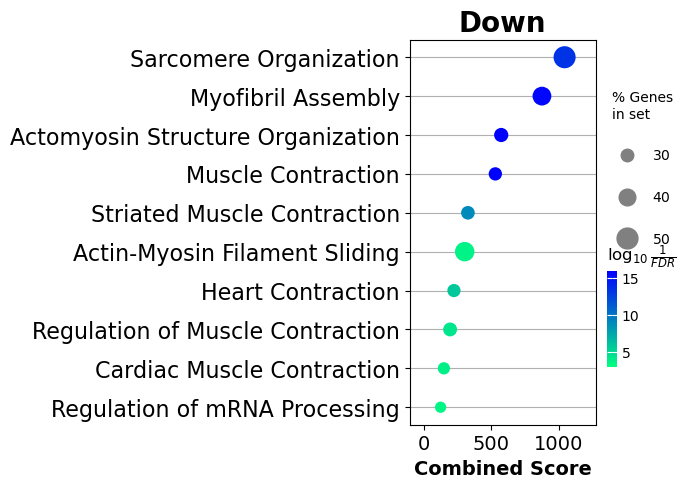

In [180]:
enr_dw.res2d.Term = enr_dw.res2d.Term.str.split(" \(GO").str[0]
gp.dotplot(enr_dw.res2d,
           figsize=(3,5),
           title="Down",
           cmap = plt.cm.winter_r,
           size=5)
plt.show()